# Experimentation and Uplift Testing

## 1. Business Objective

The objective of this analysis is to evaluate the impact of trial layouts in selected stores by comparing their sales performance against similar control stores.

In [162]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load and Inspect Data

In [163]:
# Load dataset
data = pd.read_csv("QVI_data.csv")

# View first rows
data.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [164]:
# Check dataset structure
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264834 non-null  int64  
 1   DATE              264834 non-null  object 
 2   STORE_NBR         264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  object 
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  object 
 10  LIFESTAGE         264834 non-null  object 
 11  PREMIUM_CUSTOMER  264834 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 24.2+ MB


In [165]:
data.describe()

,LYLTY_CARD_NBR,STORE_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES,PACK_SIZE
count,2.648340e+05,264834.000000,2.648340e+05,264834.000000,264834.000000,264834.000000,264834.000000
mean,1.355488e+05,135.079423,1.351576e+05,56.583554,1.905813,7.299346,182.425512
std,8.057990e+04,76.784063,7.813292e+04,32.826444,0.343436,2.527241,64.325148
min,1.000000e+03,1.000000,1.000000e+00,1.000000,1.000000,1.500000,70.000000
25%,7.002100e+04,70.000000,6.760050e+04,28.000000,2.000000,5.400000,150.000000
50%,1.303570e+05,130.000000,1.351365e+05,56.000000,2.000000,7.400000,170.000000
75%,2.030940e+05,203.000000,2.026998e+05,85.000000,2.000000,9.200000,175.000000
max,2.373711e+06,272.000000,2.415841e+06,114.000000,5.000000,29.500000,380.000000


In [166]:
# Convert DATE column to datetime format
data['DATE'] = pd.to_datetime(data['DATE'])

# Create a year-month column
data['YEARMONTH'] = data['DATE'].dt.to_period('M')

In [167]:
data["YEARMONTH"].sort_values().unique()

<PeriodArray>
['2018-07', '2018-08', '2018-09', '2018-10', '2018-11', '2018-12', '2019-01',
 '2019-02', '2019-03', '2019-04', '2019-05', '2019-06']
Length: 12, dtype: period[M]

## 3. Create Monthly Store Metrics

In [168]:
# Group transaction data by store and month
monthly_metrics = data.groupby(["STORE_NBR", "YEARMONTH"]).agg(
    
    # Total sales revenue for the month
    total_sales=("TOT_SALES", "sum"),
    
    # Number of unique customers
    total_customers=("LYLTY_CARD_NBR", "nunique"),
    
    # Number of unique transactions
    total_transactions=("TXN_ID", "nunique")

).reset_index()

In [169]:
# Average number of transactions per customer
monthly_metrics["transactions_per_customer"] = (
    monthly_metrics["total_transactions"] / monthly_metrics["total_customers"]
)

monthly_metrics.head()

,STORE_NBR,YEARMONTH,total_sales,total_customers,total_transactions,transactions_per_customer
0,1,2018-07,206.9,49,52,1.061224
1,1,2018-08,176.1,42,43,1.023810
2,1,2018-09,278.8,59,62,1.050847
3,1,2018-10,188.1,44,45,1.022727
4,1,2018-11,192.6,46,47,1.021739


## 4. Define Pre-Trial and Trial Periods

In [170]:
# Keep only months before the trial started
pretrial = monthly_metrics[monthly_metrics["YEARMONTH"] < "2019-02"]

In [171]:
# Keep only months during the trial period
trial_period = monthly_metrics[
    (monthly_metrics["YEARMONTH"] >= "2019-02") &
    (monthly_metrics["YEARMONTH"] <= "2019-04")
]

In [172]:
# Check months in pre-trial dataset
print(pretrial["YEARMONTH"].unique())
# Check months in trial dataset
print(trial_period["YEARMONTH"].unique())

<PeriodArray>
['2018-07', '2018-08', '2018-09', '2018-10', '2018-11', '2018-12', '2019-01']
Length: 7, dtype: period[M]
<PeriodArray>
['2019-02', '2019-03', '2019-04']
Length: 3, dtype: period[M]


In [173]:
# Create pivot table for total sales
sales_pivot = pretrial.pivot(
    index="YEARMONTH",
    columns="STORE_NBR",
    values="total_sales"
)

In [174]:
sales_pivot.head(7)

STORE_NBR,1,2,3,4,5,6,7,8,9,10,...,263,264,265,266,267,268,269,270,271,272
YEARMONTH,,,,,,,,,,,,,,,,,,,,,
2018-07,206.9,150.8,1205.70,1399.9,812.0,260.0,1024.7,381.6,289.7,892.00,...,38.7,232.6,247.8,127.3,6.2,224.00,982.0,962.80,956.6,433.10
2018-08,176.1,193.8,1079.75,1259.5,745.1,203.2,1119.9,383.0,327.5,878.65,...,28.0,203.3,227.1,154.5,24.9,322.65,835.1,1003.75,683.9,372.85
2018-09,278.8,154.4,1021.50,1198.6,896.0,207.7,1147.3,293.0,369.7,945.00,...,21.8,199.5,133.5,139.0,23.3,174.40,886.0,845.40,798.4,304.70
2018-10,188.1,167.8,1037.90,1346.4,798.0,292.4,1063.9,422.8,361.0,910.80,...,36.6,170.0,162.9,170.4,14.4,237.60,1078.4,816.40,790.0,430.60
2018-11,192.6,162.9,1008.00,1212.0,771.4,255.3,1076.5,349.2,374.4,885.00,...,15.8,184.5,282.8,144.2,40.3,225.40,967.2,965.00,886.4,376.20
2018-12,189.6,136.0,1121.60,1185.6,879.2,209.1,906.1,356.4,382.6,936.60,...,24.6,288.5,205.3,157.8,15.4,207.30,935.4,1038.00,807.4,403.90
2019-01,154.8,162.8,1051.70,1525.0,838.0,191.1,975.1,445.0,399.4,878.60,...,21.3,247.3,176.7,148.7,34.4,157.70,980.4,1066.60,842.4,423.00


In [175]:
sales_pivot.isna().sum()[sales_pivot.isna().sum() > 0]

STORE_NBR
11     5
31     5
44     1
76     6
85     6
117    1
193    6
206    6
211    6
218    1
252    6
dtype: int64

In [176]:
# Remove stores with missing monthly sales data
sales_pivot = sales_pivot.dropna(axis=1)

In [177]:
# Calculate correlation with Store 77
corr_77 = sales_pivot.corrwith(sales_pivot[77])

# Sort from highest to lowest similarity
corr_77.sort_values(ascending=False).head(10)

STORE_NBR
77     1.000000
71     0.914106
233    0.903774
119    0.867664
17     0.842668
3      0.806644
41     0.783232
50     0.763866
157    0.735893
162    0.729740
dtype: float64

In [178]:
# Calculate absolute difference from Store 77
magnitude_77 = abs(sales_pivot.subtract(sales_pivot[77], axis=0))

In [179]:
# Average monthly sales difference for each store
magnitude_77 = magnitude_77.mean().sort_values()

In [180]:
magnitude_77.head(10)

STORE_NBR
77      0.000000
233    18.828571
255    28.571429
188    31.100000
53     32.471429
131    33.042857
46     33.228571
214    34.442857
50     34.714286
205    36.057143
dtype: float64

In [181]:
# Convert distance into similarity score
magnitude_similarity_77 = 1 - (
    (magnitude_77 - magnitude_77.min()) /
    (magnitude_77.max() - magnitude_77.min())
)

In [182]:
# Combine correlation and magnitude similarity
final_score_77 = pd.concat(
    [corr_77, magnitude_similarity_77],
    axis=1
)

# Rename columns
final_score_77.columns = [
    "correlation",
    "magnitude_similarity"
]

In [183]:
# Average the two similarity measures
final_score_77["final_score"] = (
    final_score_77["correlation"] +
    final_score_77["magnitude_similarity"]
) / 2

In [184]:
# Sort stores by final similarity score
final_score_77.sort_values(
    by="final_score",
    ascending=False
).head(10)

,correlation,magnitude_similarity,final_score
STORE_NBR,,,
77,1.000000,1.000000,1.000000
233,0.903774,0.984567,0.944171
41,0.783232,0.962834,0.873033
50,0.763866,0.971546,0.867706
17,0.842668,0.872450,0.857559
115,0.689159,0.928151,0.808655
167,0.657110,0.956160,0.806635
265,0.639759,0.960434,0.800097
234,0.696325,0.882227,0.789276


## 5. Control Store Selection for Store 77

In [185]:
control_store_77 = 233

In [186]:
# Get monthly data for trial store 77
trial_77 = monthly_metrics[
    monthly_metrics["STORE_NBR"] == 77
]

# Get monthly data for control store
control_77 = monthly_metrics[
    monthly_metrics["STORE_NBR"] == control_store_77
]

## 6. Trial Assessment for Store 77

In [187]:
# Merge trial and control store data by month
comparison_77 = pd.merge(
    trial_77,
    control_77,
    on="YEARMONTH",
    suffixes=("_trial", "_control")
)

In [188]:
comparison_77.head(20)

,STORE_NBR_trial,YEARMONTH,total_sales_trial,total_customers_trial,total_transactions_trial,transactions_per_customer_trial,STORE_NBR_control,total_sales_control,total_customers_control,total_transactions_control,transactions_per_customer_control
0,77,2018-07,296.8,51,55,1.078431,233,290.7,51,54,1.058824
1,77,2018-08,255.5,47,48,1.021277,233,285.9,48,50,1.041667
2,77,2018-09,225.2,42,44,1.047619,233,228.6,42,45,1.071429
3,77,2018-10,204.5,37,38,1.027027,233,185.7,35,36,1.028571
4,77,2018-11,245.3,41,44,1.073171,233,211.6,40,41,1.025000
5,77,2018-12,267.3,46,48,1.043478,233,279.8,47,50,1.063830
6,77,2019-01,204.4,35,39,1.114286,233,177.5,35,35,1.000000
7,77,2019-02,235.0,45,45,1.000000,233,244.0,45,47,1.044444
8,77,2019-03,278.5,50,55,1.100000,233,199.1,40,41,1.025000
9,77,2019-04,263.5,47,48,1.021277,233,158.6,30,32,1.066667


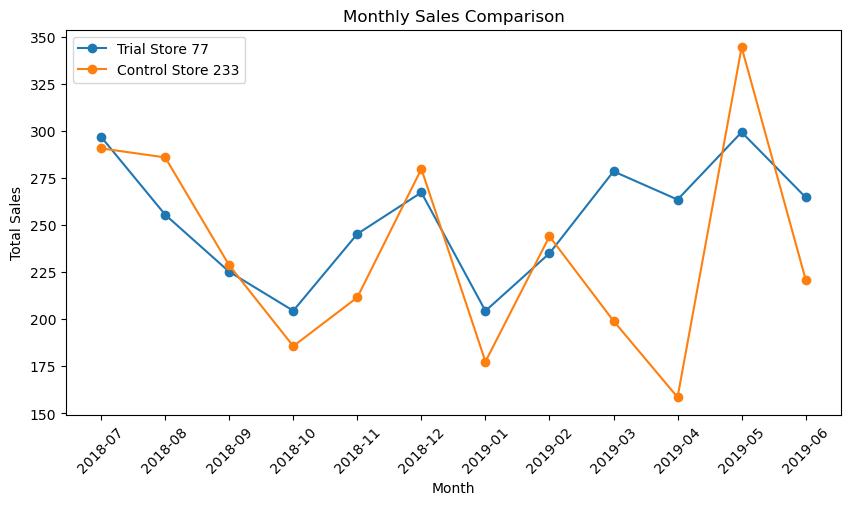

In [189]:
# Plot trial vs control sales
plt.figure(figsize=(10,5))

plt.plot(
    comparison_77["YEARMONTH"].astype(str),
    comparison_77["total_sales_trial"],
    marker='o',
    label="Trial Store 77"
)

plt.plot(
    comparison_77["YEARMONTH"].astype(str),
    comparison_77["total_sales_control"],
    marker='o',
    label=f"Control Store {control_store_77}"
)

plt.title("Monthly Sales Comparison")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [190]:
# Filter pre-trial months
pretrial_comparison = comparison_77[
    comparison_77["YEARMONTH"] < "2019-02"
]

In [191]:
# Ratio of trial sales to control sales
sales_ratio = (
    pretrial_comparison["total_sales_trial"] /
    pretrial_comparison["total_sales_control"]
)

In [192]:
# Average ratio during pre-trial period
mean_ratio = sales_ratio.mean()

# Standard deviation of ratio
std_ratio = sales_ratio.std()

print("Mean Ratio:", mean_ratio)
print("Std Dev:", std_ratio)

Mean Ratio: 1.0381650930238628
Std Dev: 0.10193843267893225


In [193]:
# Filter trial months
trial_comparison = comparison_77[
    (comparison_77["YEARMONTH"] >= "2019-02") &
    (comparison_77["YEARMONTH"] <= "2019-04")
]

In [194]:
# Trial-period ratios
trial_ratio = (
    trial_comparison["total_sales_trial"] /
    trial_comparison["total_sales_control"]
)

In [195]:
# Calculate t-values for trial months
t_values = (trial_ratio - mean_ratio) / std_ratio

print(t_values)

7   -0.736232
8    3.537719
9    6.113958
dtype: float64


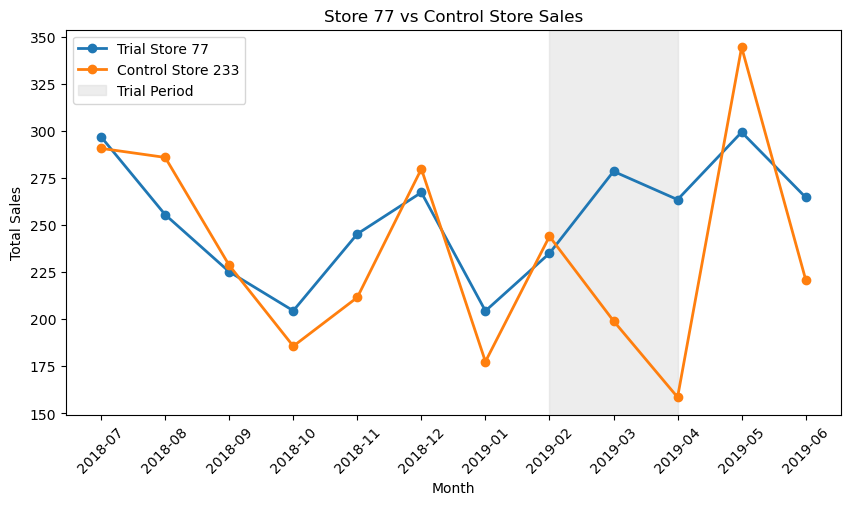

In [196]:
# Create sales comparison plot
plt.figure(figsize=(10,5))

# Trial store sales
plt.plot(
    comparison_77["YEARMONTH"].astype(str),
    comparison_77["total_sales_trial"],
    marker='o',
    linewidth=2,
    label="Trial Store 77"
)

# Control store sales
plt.plot(
    comparison_77["YEARMONTH"].astype(str),
    comparison_77["total_sales_control"],
    marker='o',
    linewidth=2,
    label=f"Control Store {control_store_77}"
)

# Highlight trial period
plt.axvspan("2019-02", "2019-04",
            color='lightgrey',
            alpha=0.4,
            label="Trial Period")

# Titles and labels
plt.title("Store 77 vs Control Store Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.legend()

plt.show()

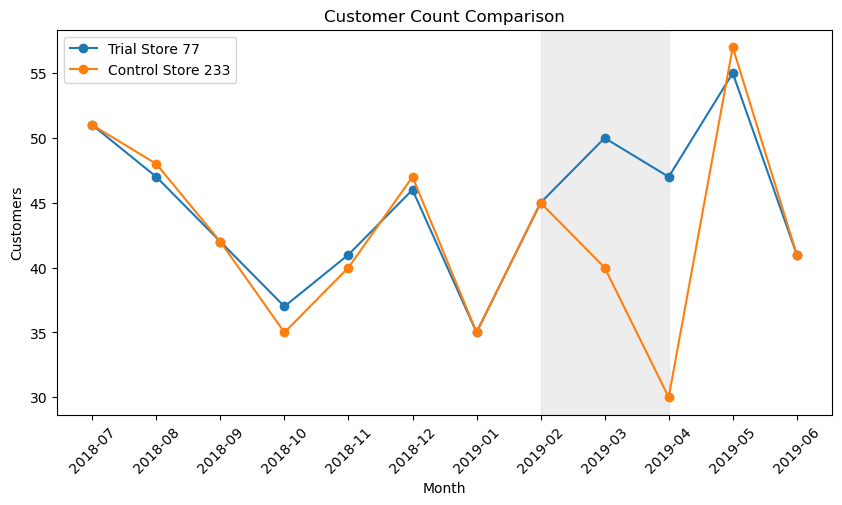

In [197]:
plt.figure(figsize=(10,5))

plt.plot(
    comparison_77["YEARMONTH"].astype(str),
    comparison_77["total_customers_trial"],
    marker='o',
    label="Trial Store 77"
)

plt.plot(
    comparison_77["YEARMONTH"].astype(str),
    comparison_77["total_customers_control"],
    marker='o',
    label=f"Control Store {control_store_77}"
)

plt.axvspan("2019-02", "2019-04",
            color='lightgrey',
            alpha=0.4)

plt.title("Customer Count Comparison")
plt.xlabel("Month")
plt.ylabel("Customers")

plt.xticks(rotation=45)
plt.legend()

plt.show()

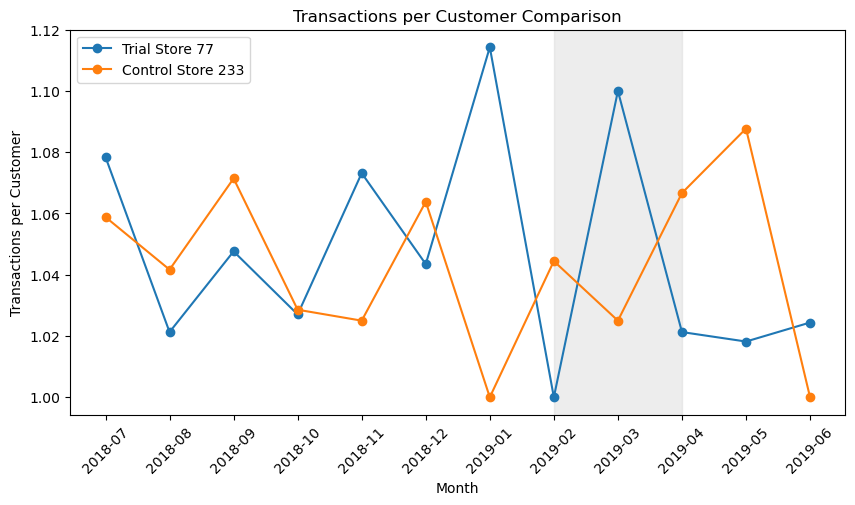

In [198]:
plt.figure(figsize=(10,5))

plt.plot(
    comparison_77["YEARMONTH"].astype(str),
    comparison_77["transactions_per_customer_trial"],
    marker='o',
    label="Trial Store 77"
)

plt.plot(
    comparison_77["YEARMONTH"].astype(str),
    comparison_77["transactions_per_customer_control"],
    marker='o',
    label=f"Control Store {control_store_77}"
)

plt.axvspan("2019-02", "2019-04",
            color='lightgrey',
            alpha=0.4)

plt.title("Transactions per Customer Comparison")
plt.xlabel("Month")
plt.ylabel("Transactions per Customer")

plt.xticks(rotation=45)
plt.legend()

plt.show()

## 7. Automating Control Store Selection

In [199]:
def find_control_store(trial_store):
    
    # Create pivot table for sales
    sales_pivot = pretrial.pivot(
        index="YEARMONTH",
        columns="STORE_NBR",
        values="total_sales"
    )
    
    # Remove stores with missing values
    sales_pivot = sales_pivot.dropna(axis=1)
    
    # Correlation scores
    corr = sales_pivot.corrwith(sales_pivot[trial_store])
    
    # Magnitude distance
    magnitude = abs(
        sales_pivot.subtract(
            sales_pivot[trial_store],
            axis=0
        )
    ).mean()
    
    # Convert distance to similarity
    magnitude_similarity = 1 - (
        (magnitude - magnitude.min()) /
        (magnitude.max() - magnitude.min())
    )
    
    # Combine metrics
    final_score = pd.concat(
        [corr, magnitude_similarity],
        axis=1
    )
    
    final_score.columns = [
        "correlation",
        "magnitude_similarity"
    ]
    
    # Average score
    final_score["final_score"] = (
        final_score["correlation"] +
        final_score["magnitude_similarity"]
    ) / 2

    # Remove the trial store itself from the control store candidates
    final_score = final_score.drop(index=trial_store)
    
    # Sort stores
    final_score = final_score.sort_values(
        by="final_score",
        ascending=False
    )
    
    return final_score

## 8. Trial Assessment for Stores 86 and 88

In [200]:
find_control_store(86).head(10)

,correlation,magnitude_similarity,final_score
STORE_NBR,,,
155,0.877882,0.962197,0.920039
222,0.795075,0.958237,0.876656
109,0.788300,0.963195,0.875747
138,0.759864,0.923802,0.841833
114,0.734415,0.919935,0.827175
269,0.697055,0.899881,0.798468
106,0.678684,0.908872,0.793778
225,0.617533,0.956291,0.786912
128,0.654929,0.862751,0.758840


In [201]:
find_control_store(88).head(10)

,correlation,magnitude_similarity,final_score
STORE_NBR,,,
125,0.624109,0.851662,0.737885
203,0.508001,0.950114,0.729058
91,0.776688,0.659993,0.718341
7,0.649657,0.776811,0.713234
178,0.731857,0.693901,0.712879
201,0.492735,0.871894,0.682314
106,0.644724,0.698424,0.671574
79,0.576960,0.758445,0.667702
155,0.600771,0.668478,0.634625


In [202]:
def analyze_trial_store(trial_store, control_store):
    
    # Extract store data
    trial = monthly_metrics[
        monthly_metrics["STORE_NBR"] == trial_store
    ]
    
    control = monthly_metrics[
        monthly_metrics["STORE_NBR"] == control_store
    ]
    
    # Merge datasets
    comparison = pd.merge(
        trial,
        control,
        on="YEARMONTH",
        suffixes=("_trial", "_control")
    )
    
    # Pre-trial data
    pretrial_comparison = comparison[
        comparison["YEARMONTH"] < "2019-02"
    ]
    
    # Calculate normal sales ratio
    sales_ratio = (
        pretrial_comparison["total_sales_trial"] /
        pretrial_comparison["total_sales_control"]
    )
    
    mean_ratio = sales_ratio.mean()
    std_ratio = sales_ratio.std()
    
    # Trial period data
    trial_period = comparison[
        (comparison["YEARMONTH"] >= "2019-02") &
        (comparison["YEARMONTH"] <= "2019-04")
    ]
    
    # Trial ratios
    trial_ratio = (
        trial_period["total_sales_trial"] /
        trial_period["total_sales_control"]
    )
    
    # T-values
    t_values = (
        trial_ratio - mean_ratio
    ) / std_ratio
    
    print(f"\nTrial Store {trial_store}")
    print(f"Control Store {control_store}")
    print("\nT-values:")
    print(t_values)
    
    # Sales plot
    plt.figure(figsize=(10,5))
    
    plt.plot(
        comparison["YEARMONTH"].astype(str),
        comparison["total_sales_trial"],
        marker='o',
        label=f"Trial Store {trial_store}"
    )
    
    plt.plot(
        comparison["YEARMONTH"].astype(str),
        comparison["total_sales_control"],
        marker='o',
        label=f"Control Store {control_store}"
    )
    
    plt.axvspan(
        "2019-02",
        "2019-04",
        color='lightgrey',
        alpha=0.4
    )
    
    plt.title(f"Sales Comparison: Store {trial_store}")
    plt.xlabel("Month")
    plt.ylabel("Total Sales")
    
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()


Trial Store 77
Control Store 233

T-values:
7   -0.736232
8    3.537719
9    6.113958
dtype: float64


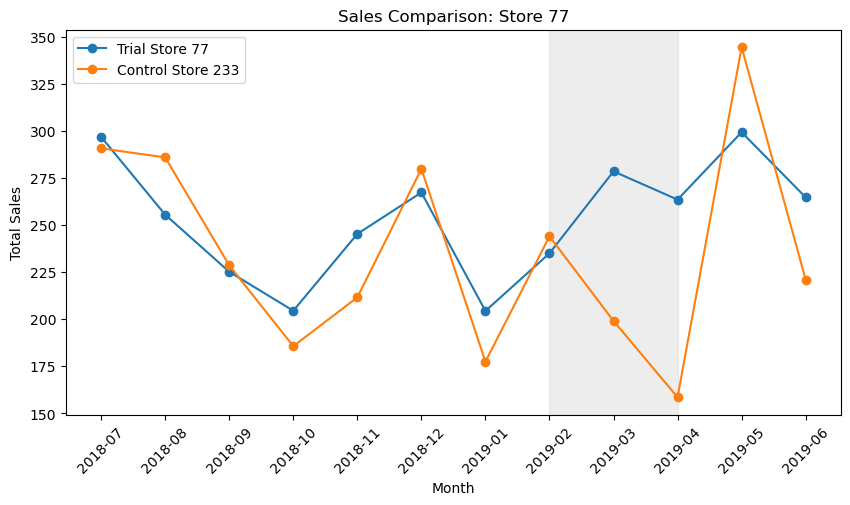

In [203]:
analyze_trial_store(77, 233)


Trial Store 86
Control Store 155

T-values:
7    1.456624
8    8.344279
9    0.897953
dtype: float64


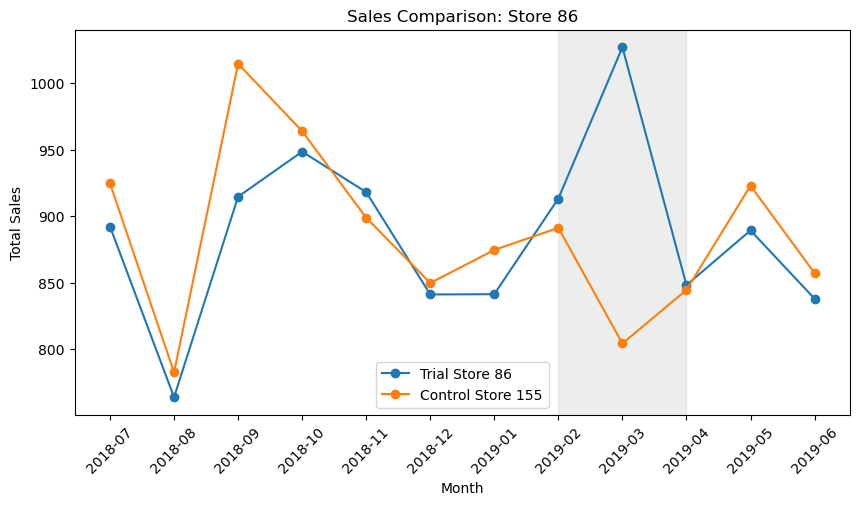

In [204]:
analyze_trial_store(86, 155)


Trial Store 88
Control Store 125

T-values:
7    6.004032
8    0.407732
9    2.328788
dtype: float64


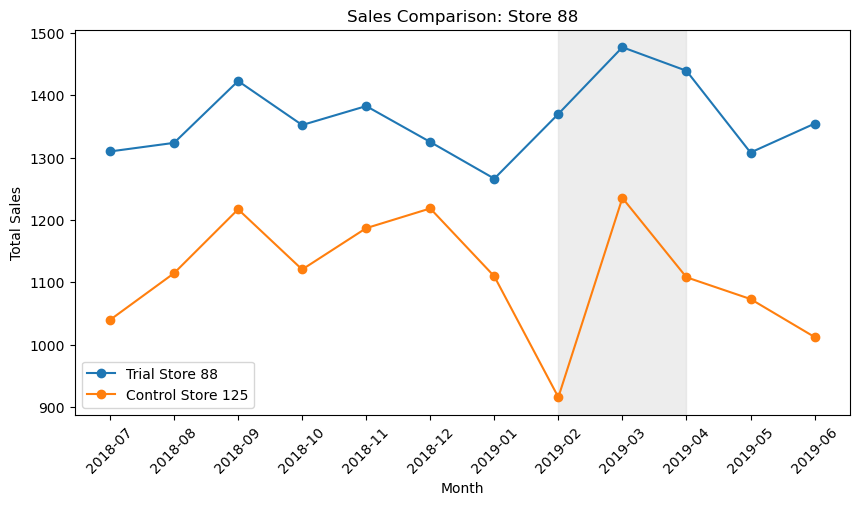

In [205]:
analyze_trial_store(88, 125)

## 9. Final Findings and Recommendations

In [206]:
# Improve dataframe display
pd.set_option('display.max_colwidth', None)

# Create improved summary table
summary = pd.DataFrame({

    "Trial Store": [77, 86, 88],

    "Control Store": [233, 155, 125],

    "Significant Trial Months": [
        "March and April",
        "March only",
        "February and April"
    ],

    "Key Findings": [

        "Store 77 showed strong and sustained sales uplift during March and April 2019. The uplift was primarily driven by increased customer counts during the trial period.",

        "Store 86 showed a significant uplift in March 2019; however, the improvement was not sustained across the entire trial period.",

        "Store 88 showed some evidence of uplift, though the control store match was weaker compared to the other trial stores."
    ],

    "Recommendation": [

        "Recommend considering rollout of the new layout to similar stores.",

        "Recommend further monitoring before implementing a full rollout.",

        "Interpret results cautiously and conduct additional validation before rollout."
    ]
})

# Display summary
summary.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap'
})

,Trial Store,Control Store,Significant Trial Months,Key Findings,Recommendation
0,77,233,March and April,Store 77 showed strong and sustained sales uplift during March and April 2019. The uplift was primarily driven by increased customer counts during the trial period.,Recommend considering rollout of the new layout to similar stores.
1,86,155,March only,"Store 86 showed a significant uplift in March 2019; however, the improvement was not sustained across the entire trial period.",Recommend further monitoring before implementing a full rollout.
2,88,125,February and April,"Store 88 showed some evidence of uplift, though the control store match was weaker compared to the other trial stores.",Interpret results cautiously and conduct additional validation before rollout.
